In [1]:
!pip install ultralytics pandas matplotlib seaborn -q

print("✅ Packages installed successfully!")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 41.0/41.0 kB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 24.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 1.7 MB/s eta 0:00:00
✅ Packages installed successfully!


In [2]:
from ultralytics import YOLO
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import os

sns.set_style("whitegrid")
print("✅ Libraries imported")

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
✅ Libraries imported


In [3]:
# Load segmentation model
model = YOLO("yolo11s-seg.pt")   # Small & fast. You can use 'yolo11m-seg.pt' or 'yolo11l-seg.pt' for better accuracy

print("✅ YOLO11 Segmentation model loaded!")

✅ YOLO11 Segmentation model loaded!


In [6]:
def analyze_instance_segmentation(image_path):
    """Fixed: Full Instance Segmentation + Area + Color Analysis"""

    # Load image
    if image_path.startswith("http"):
        import requests
        resp = requests.get(image_path)
        img = cv2.imdecode(np.frombuffer(resp.content, np.uint8), 1)
    else:
        img = cv2.imread(image_path)

    if img is None:
        print("❌ Error loading image")
        return None, None

    rgb_img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    h, w = rgb_img.shape[:2]

    # Run segmentation
    results = model(rgb_img, conf=0.4, verbose=False)

    print(f"🎯 Detected {len(results[0].boxes)} objects\n")

    data = []

    for i, (box, mask_tensor) in enumerate(zip(results[0].boxes, results[0].masks.data)):
        cls_name = results[0].names[int(box.cls)]
        confidence = float(box.conf)

        # Convert mask and RESIZE to original image size
        mask = mask_tensor.cpu().numpy()
        mask_resized = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)

        # Calculate area
        area_pixels = np.sum(mask_resized > 0.5)

        # Get color inside the object
        masked_img = rgb_img.copy()
        masked_img[~mask_resized.astype(bool)] = 0
        mean_color = np.mean(masked_img[mask_resized.astype(bool)], axis=0).astype(int)

        data.append({
            "Object": i+1,
            "Class": cls_name,
            "Confidence": round(confidence, 3),
            "Area (pixels)": area_pixels,
            "Mean Color (R,G,B)": tuple(mean_color)
        })

        print(f"Object {i+1}: {cls_name} | Area: {area_pixels} pixels | Color: {tuple(mean_color)}")

    df = pd.DataFrame(data)

    # Visualization
    plt.figure(figsize=(20, 8))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb_img)
    plt.title("Original Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    annotated = results[0].plot()
    plt.imshow(cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB))
    plt.title("YOLO11 Instance Segmentation")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    combined_mask = np.zeros((h, w), dtype=np.float32)
    for mask_tensor in results[0].masks.data:
        mask = mask_tensor.cpu().numpy()
        mask_resized = cv2.resize(mask, (w, h), interpolation=cv2.INTER_NEAREST)
        combined_mask += mask_resized
    plt.imshow(combined_mask, cmap='jet')
    plt.title("Combined Masks")
    plt.colorbar()
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    return df, results

🎯 Detected 5 objects

Object 1: person | Area: 23511 pixels | Color: (np.int64(35), np.int64(35), np.int64(56))
Object 2: person | Area: 52694 pixels | Color: (np.int64(124), np.int64(108), np.int64(102))
Object 3: bus | Area: 258410 pixels | Color: (np.int64(88), np.int64(100), np.int64(116))
Object 4: person | Area: 36083 pixels | Color: (np.int64(53), np.int64(50), np.int64(66))
Object 5: person | Area: 10821 pixels | Color: (np.int64(99), np.int64(87), np.int64(83))


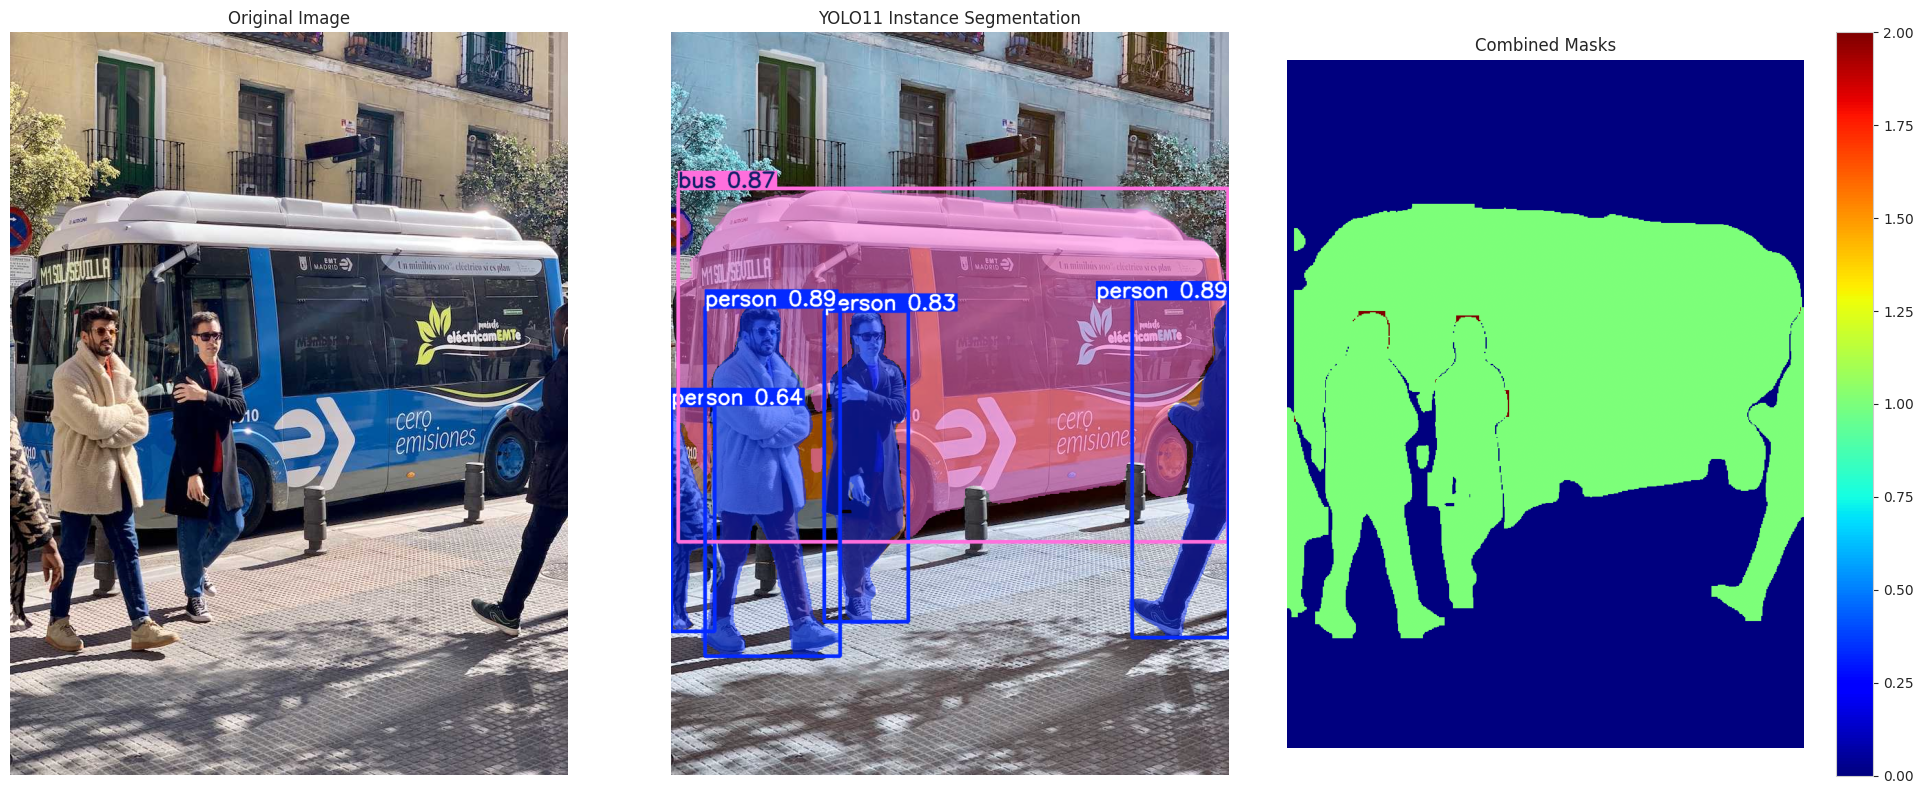

In [7]:
#test
df1, res1 = analyze_instance_segmentation("https://ultralytics.com/images/bus.jpg")


📊 Detailed Analysis Report
   Object   Class  Confidence  Area (pixels) Mean Color (R,G,B)
0       1  person       0.889          23511       (35, 35, 56)
1       2  person       0.888          52694    (124, 108, 102)
2       3     bus       0.871         258410     (88, 100, 116)
3       4  person       0.830          36083       (53, 50, 66)
4       5  person       0.642          10821       (99, 87, 83)


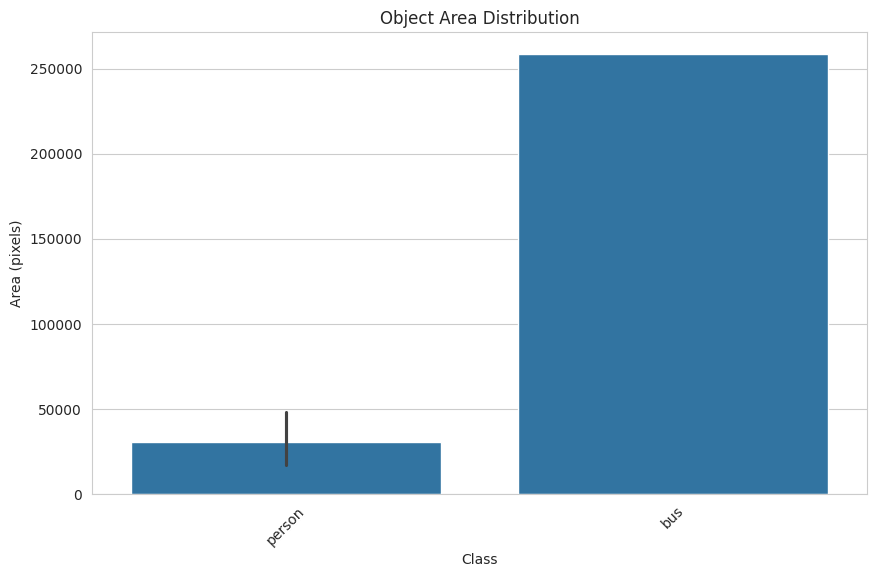

In [9]:
# After running analysis
print("📊 Detailed Analysis Report")
print(df1)

# Plot area distribution
plt.figure(figsize=(10, 6))
sns.barplot(data=df1, x="Class", y="Area (pixels)")
plt.title("Object Area Distribution")
plt.xticks(rotation=45)
plt.show()

In [ ]:
from ultralytics import YOLO
import cv2
import matplotlib.pyplot as plt
import requests
import numpy as np
from IPython.display import display, Image as IPyImage

# Load Model
model = YOLO("yolo11s.pt")

def detect_thermal_heatmap(image_path):
    """Thermal-style visualization with heat colormap"""

    # Load image
    if image_path.startswith("http"):
        resp = requests.get(image_path)
        img = cv2.imdecode(np.frombuffer(resp.content, np.uint8), 1)
    else:
        img = cv2.imread(image_path)

    if img is None:
        print("❌ Error loading image")
        return

    rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    # Run YOLO Detection
    results = model(rgb, conf=0.4, verbose=False)

    print(f"🔥 Detected {len(results[0].boxes)} objects\n")
    for box in results[0].boxes:
        cls = results[0].names[int(box.cls)]
        conf = float(box.conf)
        print(f"→ {cls} | Confidence: {conf:.3f}")

    # Create Thermal-style Heatmap
    # Convert to grayscale and apply colormap
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    thermal = cv2.applyColorMap(gray, cv2.COLORMAP_INFERNO)   # Good thermal look

    # Overlay detections on thermal image
    annotated_thermal = results[0].plot(img=thermal)

    # Show results
    plt.figure(figsize=(20, 10))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title("Original RGB Image")
    plt.axis('off')

    plt.subplot(1, 3, 2)
    plt.imshow(cv2.cvtColor(thermal, cv2.COLOR_BGR2RGB))
    plt.title("Thermal Heatmap (Red = Hot, Purple = Cold)")
    plt.axis('off')

    plt.subplot(1, 3, 3)
    plt.imshow(cv2.cvtColor(annotated_thermal, cv2.COLOR_BGR2RGB))
    plt.title("YOLO Detection + Thermal Overlay")
    plt.axis('off')

    plt.tight_layout()
    plt.show()

    print("✅ Red/Yellow = High Temperature | Purple/Blue = Low Temperature")

# ============= TEST =============
detect_thermal_heatmap("https://ultralytics.com/images/bus.jpg")

🔥 Detected 5 objects

→ bus | Confidence: 0.920
→ person | Confidence: 0.885
→ person | Confidence: 0.882
→ person | Confidence: 0.874
→ person | Confidence: 0.655


In [15]:
# Cell: Multi-Camera Tracking Demo

from ultralytics import YOLO
import cv2

model = YOLO("yolo11s.pt")

def multi_camera_demo(video1_path, video2_path):
    cap1 = cv2.VideoCapture(video1_path)
    cap2 = cv2.VideoCapture(video2_path)

    print("🎥 Simulating Multi-Camera Tracking...")

    frame_count = 0
    while True:
        ret1, frame1 = cap1.read()
        ret2, frame2 = cap2.read()

        if not ret1 or not ret2 or frame_count > 100:   # Limit for demo
            break

        # Track on both cameras
        res1 = model.track(frame1, persist=True, tracker="bytetrack.yaml", verbose=False)
        res2 = model.track(frame2, persist=True, tracker="bytetrack.yaml", verbose=False)

        # In real system, you would use ReID to match same person across cameras
        annotated1 = res1[0].plot()
        annotated2 = res2[0].plot()

        # Show side by side
        combined = np.hstack((annotated1, annotated2))
        cv2.imshow("Camera 1 | Camera 2", combined)

        if cv2.waitKey(1) & 0xFF == ord('q'):
            break

        frame_count += 1

    cap1.release()
    cap2.release()
    cv2.destroyAllWindows()

print("✅ Multi-camera tracking function ready")

✅ Multi-camera tracking function ready
